### Name: Shruti Sharma (MDS202435)
### Name: Riya Shyam Huddar(MDS202431)

### AML Assignment 3 (Discrete)

In [1]:
# importing required libraries

import random
import math
import os
from collections import namedtuple, deque
from itertools import count

import numpy as np
import matplotlib.pyplot as plt
import imageio

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import gymnasium as gym

In [2]:
# Gymnasium already has the enviornment setup for lunar lander.
# The physics, rewards, state and action space are all defined there.

# configuration and hyperparameters
ENV_NAME = "LunarLander-v3"   
SEED = 42 #

# 1 episode is 1 attempt to land the lunar module
NUM_EPISODES = 1000         
MIN_REPLAY_SIZE = 1000     

BATCH_SIZE = 64 
GAMMA = 0.99
LR = 1e-4
REPLAY_CAPACITY = 100_000

TARGET_UPDATE_FREQ = 1000  
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY = 40_000         
GRAD_CLIP = 1.0
SAVE_GIFS = False          
GIF_DIR = "./gifs"
MODEL_PATH = "dqn_lunar_model_discrete.pt"
PRINT_EVERY = 10

In [3]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


CUDA available: True
CUDA version: 12.6
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [5]:
# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))

# replay nemory class to store experience tuples
class ReplayMemory:
    def __init__(self, capacity):
        self.capacity = capacity
        self.memory = deque(maxlen=capacity)
    def push(self, *args):
        self.memory.append(Transition(*args))
    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)
    def __len__(self):
        return len(self.memory)

In [ ]:
# using neural network as function approximator for Q-value function
# Q value is the expected future reward for taking an action in a given state
class DQN(nn.Module):
    def __init__(self, input_dim, n_actions, hidden=128):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.out = nn.Linear(hidden, n_actions)
        nn.init.kaiming_uniform_(self.fc1.weight, nonlinearity='relu')
        nn.init.kaiming_uniform_(self.fc2.weight, nonlinearity='relu')
        nn.init.xavier_uniform_(self.out.weight)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.out(x)

In [ ]:
# controls the value of epsilon for epsilon-greedy action selection
def epsilon_by_step(step):
    return EPS_END + (EPS_START - EPS_END) * math.exp(-1. * step / EPS_DECAY)

In [ ]:
# selects action using epsilon-greedy policy
def select_action(state_tensor, policy_net, steps_done, n_actions, train=True):
    sample = random.random()
    eps_threshold = epsilon_by_step(steps_done)
    with torch.no_grad():
        qvals = policy_net(state_tensor) 
        greedy_action = qvals.max(1)[1].item()
    if train and sample < eps_threshold:
        return random.randrange(n_actions), eps_threshold
    else:
        return greedy_action, eps_threshold

In [ ]:
# plots episode rewards and their moving average
def plot_durations(episode_rewards, window=100, title="Episode rewards"):
    plt.figure(figsize=(10,5))
    plt.plot(episode_rewards, label='episode reward')
    if len(episode_rewards) >= window:
        smooth = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
        plt.plot(range(window-1, window-1+len(smooth)), smooth, label=f'{window}-episode avg', color='orange')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
"""
# samples a batch from replay memory 
# computes the DQN loss
# calculates error between predicted Q-values and target Q-values
# backpropagates the loss and updates the weights of the policy network
"""

def optimize_model(memory, policy_net, target_net, optimizer):
    if len(memory) < BATCH_SIZE:
        return None
    transitions = memory.sample(BATCH_SIZE)
    batch = Transition(*zip(*transitions))

    non_final_mask = torch.tensor([s is not None for s in batch.next_state], device=device, dtype=torch.bool)

    state_batch = torch.cat([torch.tensor([s], dtype=torch.float32, device=device) for s in batch.state])
    action_batch = torch.cat([torch.tensor([[a]], dtype=torch.int64, device=device) for a in batch.action])  # (B,1)
    reward_batch = torch.cat([torch.tensor([r], dtype=torch.float32, device=device) for r in batch.reward])    # (B,)

    if non_final_mask.any():
        non_final_next_states = torch.cat([torch.tensor([s], dtype=torch.float32, device=device)
                                           for s in batch.next_state if s is not None])
    else:
        non_final_next_states = torch.empty((0, state_batch.size(1)), device=device)

    state_action_values = policy_net(state_batch).gather(1, action_batch)  # (B,1)

    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    if non_final_next_states.size(0) > 0:
        next_q = target_net(non_final_next_states)
        next_state_values[non_final_mask] = next_q.max(1)[0].detach()

    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values.squeeze(1), expected_state_action_values)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), GRAD_CLIP)
    optimizer.step()

    return loss.item()

In [ ]:
# Main training loop

def train():
    env = gym.make(ENV_NAME)
    # seed for reproducibility
    np.random.seed(SEED)
    random.seed(SEED)
    torch.manual_seed(SEED)

    # seed env and spaces (Gymnasium style)
    obs, info = env.reset(seed=SEED)
    try:
        env.action_space.seed(SEED)
    except Exception:
        pass
    try:
        env.observation_space.seed(SEED)
    except Exception:
        pass

    state_dim = len(obs)
    n_actions = env.action_space.n

    # initialize policy and target networks
    policy_net = DQN(input_dim=state_dim, n_actions=n_actions).to(device)
    target_net = DQN(input_dim=state_dim, n_actions=n_actions).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.RMSprop(policy_net.parameters(), lr=LR)
    memory = ReplayMemory(REPLAY_CAPACITY)

    steps_done = 0
    episode_rewards = []
    losses = []
    total_steps = 0

    # Prefill replay memory with random actions
    print("Prefilling replay memory with random actions...")
    obs, info = env.reset()
    s = obs
    for _ in range(MIN_REPLAY_SIZE):
        a = env.action_space.sample()
        step_out = env.step(a)
        if len(step_out) == 5:
            s2, r, terminated, truncated, info = step_out
            done = terminated or truncated
        else:
            s2, r, done, info = step_out
        memory.push(np.array(s, dtype=np.float32), a, (np.array(s2, dtype=np.float32) if not done else None), float(r))
        if done:
            obs, info = env.reset()
            s = obs
        else:
            s = s2

    # actual training loop
    print("Starting training...")
    for i_episode in range(1, NUM_EPISODES+1):
        obs, info = env.reset()
        state = np.array(obs, dtype=np.float32)
        total_reward = 0

        # loop until episode ends
        for t in count():
            state_tensor = torch.tensor([state], dtype=torch.float32, device=device)
            action, eps = select_action(state_tensor, policy_net, steps_done, n_actions, train=True)
            steps_done += 1
            total_steps += 1

            step_out = env.step(action)
            if len(step_out) == 5:
                next_obs, reward, terminated, truncated, info = step_out
                done = terminated or truncated
            else:
                next_obs, reward, done, info = step_out

            next_state = None if done else np.array(next_obs, dtype=np.float32)

            memory.push(state, action, next_state, float(reward))
            state = next_state if next_state is not None else state
            total_reward += reward

            loss = optimize_model(memory, policy_net, target_net, optimizer)
            if loss is not None:
                losses.append(loss)

            if total_steps % TARGET_UPDATE_FREQ == 0:
                target_net.load_state_dict(policy_net.state_dict())

            if done:
                episode_rewards.append(total_reward)
                break
        
        # print progress
        if i_episode % PRINT_EVERY == 0:
            recent = episode_rewards[-PRINT_EVERY:]
            print(f"Episode {i_episode}\tAvg Reward (last {PRINT_EVERY}): {np.mean(recent):.2f}\tEpsilon: {eps:.3f}\tReplaySize: {len(memory)}")

    torch.save(policy_net.state_dict(), MODEL_PATH)
    print("Training complete. Model saved to", MODEL_PATH)

    plot_durations(episode_rewards, window=100, title="DQN on LunarLander")

    env.close()
    return policy_net, episode_rewards

In [ ]:
# Evaluation function
def evaluate(policy_net, n_games=20, save_gif=False, gif_path=GIF_DIR):
    env = gym.make(ENV_NAME, render_mode='rgb_array')
    np.random.seed(SEED + 1)
    random.seed(SEED + 1)
    torch.manual_seed(SEED + 1)

    obs, info = env.reset(seed=SEED+1)
    try:
        env.action_space.seed(SEED+1)
    except Exception:
        pass

    n_actions = env.action_space.n
    rewards = []
    if save_gif and not os.path.exists(gif_path):
        os.makedirs(gif_path)

    # we have taken n_games to be number of evaluation episodes
    for i in range(n_games):
        obs, info = env.reset()
        state = np.array(obs, dtype=np.float32)
        total_reward = 0
        frames = []
        for t in range(1000):
            state_tensor = torch.tensor([state], dtype=torch.float32, device=device)
            with torch.no_grad():
                action = policy_net(state_tensor).max(1)[1].item()
            step_out = env.step(action)
            if len(step_out) == 5:
                next_obs, reward, terminated, truncated, info = step_out
                done = terminated or truncated
            else:
                next_obs, reward, done, info = step_out

            total_reward += reward
            try:
                frame = env.render()
                if frame is not None:
                    frames.append(frame)
            except Exception:
                pass

            if done:
                break
            state = np.array(next_obs, dtype=np.float32)

        rewards.append(total_reward)
        print(f"Eval Episode {i}\tReward: {total_reward}")
        if save_gif:
            gif_file = os.path.join(gif_path, f"eval_{i}_reward_{int(total_reward)}.gif")
            imageio.mimwrite(gif_file, frames, fps=30)
    env.close()
    print("Eval mean reward:", np.mean(rewards), "std:", np.std(rewards))
    return rewards

Prefilling replay memory with random actions...
Starting training...
Episode 10	Avg Reward (last 10): -197.86	Epsilon: 0.975	ReplaySize: 2054
Episode 20	Avg Reward (last 10): -157.77	Epsilon: 0.954	ReplaySize: 2967
Episode 30	Avg Reward (last 10): -114.12	Epsilon: 0.931	ReplaySize: 4004
Episode 40	Avg Reward (last 10): -120.15	Epsilon: 0.909	ReplaySize: 5039
Episode 50	Avg Reward (last 10): -171.66	Epsilon: 0.888	ReplaySize: 6032
Episode 60	Avg Reward (last 10): -105.91	Epsilon: 0.864	ReplaySize: 7188
Episode 70	Avg Reward (last 10): -108.60	Epsilon: 0.843	ReplaySize: 8208
Episode 80	Avg Reward (last 10): -114.89	Epsilon: 0.822	ReplaySize: 9299
Episode 90	Avg Reward (last 10): -118.26	Epsilon: 0.803	ReplaySize: 10305
Episode 100	Avg Reward (last 10): -104.53	Epsilon: 0.785	ReplaySize: 11247
Episode 110	Avg Reward (last 10): -95.97	Epsilon: 0.765	ReplaySize: 12357
Episode 120	Avg Reward (last 10): -96.24	Epsilon: 0.747	ReplaySize: 13396
Episode 130	Avg Reward (last 10): -103.10	Epsilon:

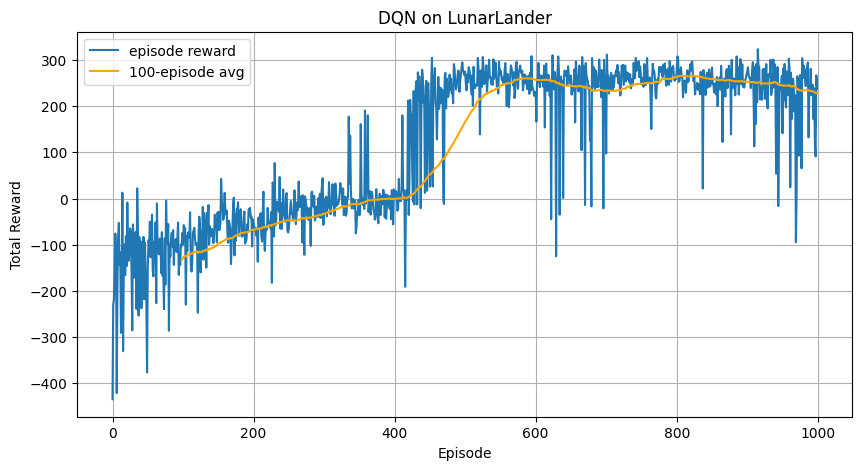

Evaluating trained policy (deterministic greedy)...


In [15]:
policy_net, rewards = train()
print("Evaluating trained policy (deterministic greedy)...")

The training logs show the agent’s performance improving steadily over the 1000 training episodes. 
- Early episodes have very low rewards (around –200), indicating frequent crashes and unstable flight. 
- As training progresses and ε (exploration rate) decreases, the agent relies more on learned Q-values, and the average episode reward increases consistently. 
- By around episode 200, the agent begins achieving moderately stable landings (rewards near –50 to 0).
- From approximately episode 800 onward, the agent regularly obtains high positive rewards (150–250), demonstrating successful and controlled landings. 
- By the end of training, the agent’s average reward over the last 10 episodes exceeds +200, which is considered a strong indication that the LunarLander task is solved. 

The replay buffer also reaches its full capacity (100,000 transitions), ensuring a diverse training dataset throughout learning.
Overall, the logs confirm that the DQN agent learned an effective landing policy through exploration, replay memory, and Q-learning updates.

In [16]:
eval_rewards = evaluate(policy_net, n_games=20, save_gif=SAVE_GIFS)
print("Done.")

Eval Episode 0	Reward: 222.17777566474712
Eval Episode 1	Reward: 259.6044581509501
Eval Episode 2	Reward: 161.16167175456042
Eval Episode 3	Reward: 136.5485765516007
Eval Episode 4	Reward: 240.92269828713822
Eval Episode 5	Reward: 227.39189184604948
Eval Episode 6	Reward: 191.1648018970144
Eval Episode 7	Reward: 248.23921666919244
Eval Episode 8	Reward: 224.83491576183354
Eval Episode 9	Reward: 135.9785277056477
Eval Episode 10	Reward: 194.37526659490584
Eval Episode 11	Reward: 202.11596412461364
Eval Episode 12	Reward: 206.93081560510933
Eval Episode 13	Reward: 220.14703209113605
Eval Episode 14	Reward: 138.40378185178403
Eval Episode 15	Reward: 294.1182095588948
Eval Episode 16	Reward: 277.60644844607447
Eval Episode 17	Reward: 188.34573537378833
Eval Episode 18	Reward: 168.10154546762482
Eval Episode 19	Reward: 279.33682151223366
Eval mean reward: 210.87530774574498 std: 46.56822748590909
Done.


We evaluated over 20 episodes using a fully greedy policy (no exploration). The results show consistently high rewards, with most episodes achieving values between 180 and 280, indicating strong landing performance. The mean reward across the 20 evaluation runs is 210.88, with a standard deviation of 46.57, reflecting both high performance and moderate variability depending on initial conditions and lander dynamics.

The results confirm that the DQN agent has successfully learned an effective strategy for solving the discrete LunarLander task.

In [ ]:
from IPython.display import Image, display


def visualize_inline(model_path="dqn_lunar_model_discrete.pt",
                     max_steps=1000,
                     seed=0,
                     gif_path="lander_inline.gif"):
    # Create env that returns RGB frames
    env = gym.make(ENV_NAME, render_mode="rgb_array")

    # Build a policy_net with correct input/output sizes
    dummy_env = gym.make(ENV_NAME)
    state_dim = dummy_env.observation_space.shape[0]
    n_actions = dummy_env.action_space.n
    dummy_env.close()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    policy_net = DQN(state_dim, n_actions).to(device)
    policy_net.load_state_dict(torch.load(model_path, map_location=device))
    policy_net.eval()

    frames = []
    obs, info = env.reset(seed=seed)

    for t in range(max_steps):
        # Store current frame
        frame = env.render()   # returns an RGB array
        if frame is not None:
            frames.append(frame)

        # Select greedy action
        state_tensor = torch.tensor([obs], dtype=torch.float32, device=device)
        with torch.no_grad():
            action = policy_net(state_tensor).max(1)[1].item()

        # Step environment
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        if done:
            # Grab final frame
            frame = env.render()
            if frame is not None:
                frames.append(frame)
            break

    env.close()

    # Save GIF
    imageio.mimsave(gif_path, frames, fps=30)
    # Display inline in the notebook
    display(Image(filename=gif_path))
    print(f"Saved and displayed GIF: {gif_path}")


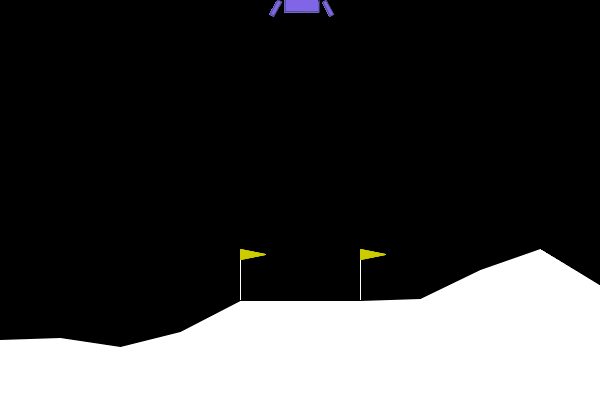

Saved and displayed GIF: lander_inline.gif


In [18]:
visualize_inline("dqn_lunar_model_discrete.pt")